In [15]:
import numpy as np
import torch
import json
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.transforms import ToTensor
from torchvision.ops import generalized_box_iou_loss
from models import imageToHandBoxCNN
from models import handToDigitsCNN
from Data import fullImageDataSet
from IPython.display import display
from PIL import Image
import matplotlib.pyplot as plt
import albumentations as A
import cv2

In [17]:
MODEL_PATH = "imageToHandBox_model.pth"
IMAGES_DIR = 'data/AUGMENTED_IMAGES'
ANNOTATIONS_DIR = 'data/AUGMENTED_IMAGES/augmented_annotations.json'

transform = transforms.Compose([
    transforms.ToTensor()
])

full_image_train_dataset = fullImageDataSet.FullImageDataSet(image_dir=IMAGES_DIR,
                                      annotation_dir=ANNOTATIONS_DIR,
                                      transform=transform)

full_image_test_dataset = fullImageDataSet.FullImageDataSet(image_dir=IMAGES_DIR,
                                      annotation_dir=ANNOTATIONS_DIR,
                                      transform=transform,
                                      train=False)

BATCH_SIZE = 64

trainDataLoader = DataLoader(full_image_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
testDataLoader = DataLoader(full_image_test_dataset, batch_size=BATCH_SIZE)
for X, y in trainDataLoader:
    print(f"Shape of X: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

device = ("cuda"
          if torch.cuda.is_available()
          else "mps"
          if torch.backends.mps.is_available()
          else "cpu"
         )
print(f"Using {device} as device")

Shape of X: torch.Size([64, 3, 512, 512])
Shape of y: torch.Size([64, 4]) torch.float32
Using mps as device


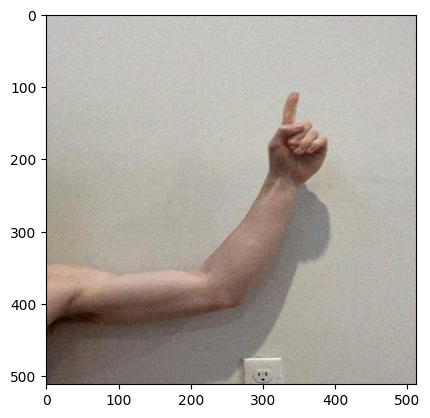

In [18]:
firstItem = full_image_test_dataset.__getitem__(200)
firstItemImage = firstItem[0].permute(1,2,0).cpu().numpy()
plt.imshow(firstItemImage)

[0.5147037506103516, 0.14974816143512726, 0.8297362327575684, 0.45921313762664795]


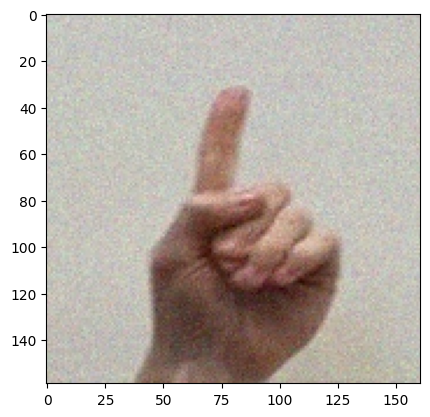

In [25]:
bounds = model(firstItem[0].to(device).unsqueeze(0))[0].tolist()
print(bounds)
intBounds = [int(bound * 512) for bound in bounds]
xmin, ymin, xmax, ymax = intBounds
croppedImage = firstItemImage[ymin:ymax, xmin:xmax]
plt.imshow(croppedImage)

In [26]:
transform = transforms.ToTensor()
croppedImage = cv2.resize(croppedImage, (256, 128), interpolation=cv2.INTER_LINEAR)
croppedImageTensor = transform(croppedImage).to(device).unsqueeze(0)
digitPred = digitModel(croppedImageTensor)
print(digitPred)

tensor([[-0.4790,  3.8244,  1.2300, -3.2961, -0.7772, -0.4312]],
       device='mps:0', grad_fn=<LinearBackward0>)


In [24]:
model = imageToHandBoxCNN.ImageToHandBoxCNN().to(device)
model.load_state_dict(torch.load("models/imageToHandBox_model.pth", weights_only=False))
model.eval()
print(model)
digitModel = handToDigitsCNN.HandToDigitsCNN().to(device)
digitModel.load_state_dict(torch.load("models/handToDigits_model.pth", weights_only=False))
digitModel.eval()
print(digitModel)

ImageToHandBoxCNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (convolutional_relu_stack): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (linear_stack): Sequential(
    (0): Linear(in_features=262144, out_features=1024, bias=True)


In [31]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

def bbox_loss(pred, target):
    return F.smooth_l1_loss(pred, target, beta=1.0)

loss_fn = bbox_loss

In [32]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (x, y) in enumerate(dataloader):
        x, y = x.to(device), y.to(device)

        pred = model(x)
        
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if (batch) % 10 == 0:
            loss, current = loss.item(), (batch + 1) * len(x)
            print(f"Loss: {loss:>7f} [{current:>5d}/{size:>5d}]")
            #print(f"Current pred: {pred.tolist()}")
            #print(f"Current real: {y.tolist()}")

In [33]:
def accuracy_fn(predicted, target):
    predicted = predicted.tolist()
    target = target.tolist()

    accuracies = []
    
    for index in range(len(target)):
        predicted_current = predicted[index]
        target_current = target[index]
        
        pXMin, pYMin, pXMax, pYMax = predicted_current
        tXMin, tYMin, tXMax, tYMax = target_current
    
        XMin = max(pXMin, tXMin)
        YMin = max(pYMin, tYMin)
        XMax = min(pXMax, tXMax)
        YMax = min(pYMax, tYMax)
    
        intersection = max(0, XMax - XMin) * max(0, YMax - YMin)
    
        pArea = (pXMax - pXMin) * (pYMax - pYMin)
        tArea = (tXMax - tXMin) * (tYMax - tYMin)
    
        union = pArea + tArea - intersection
    
        iou = intersection / union if union > 0 else 0

        accuracies.append(iou)
    return sum(accuracies) / len(accuracies)

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            test_loss += loss_fn(pred, y).item()
            correct += accuracy_fn(pred, y)

    average_loss = test_loss / num_batches
    accuracy = correct / size
    print(f"Accuracy: {accuracy}")
    print(f"Average Loss: {average_loss}")
    return accuracy, average_loss

In [34]:
def train_epochs(epochs, given_model, loss_fn, optimizer, forgiveness=1, minimum_epochs=5):
    losses = []
    accuracies = []
    average_loss_min = float('inf')
    misses = 0
    for epoch in range(epochs):
        print(f"Epoch {epoch + 1}\n------------------")
        train(trainDataLoader, given_model, loss_fn, optimizer)
        accuracy, average_loss = test(testDataLoader, given_model, loss_fn)
        losses.append(average_loss)
        accuracies.append(accuracy)
        print(f"Epoch Average Loss: {average_loss}, Min Average loss: {average_loss_min}")
        print(f"Is Epoch Avg < Min Avg?: {average_loss < average_loss_min}")
        if average_loss < average_loss_min:
            average_loss_min = average_loss
            torch.save(given_model.state_dict(), "mid_epoch_box_model.pth")
            misses = 0
        elif epoch > minimum_epochs:
            print(f"Loss increased after {epoch+1} epochs")
            misses += 1
            if misses > forgiveness:
                print("miss!")
                given_model = ImageToHandBoxCNN().to(device)
                given_model.load_state_dict(torch.load("mid_epoch_box_model.pth", weights_only=False))
                break
    return losses, accuracies

In [35]:
losses, accuracies = train_epochs(30, model, loss_fn, optimizer)
torch.save(model.state_dict(), MODEL_PATH)

Epoch 1
------------------


KeyboardInterrupt: 